# 04_prepare_weather_data_complete_fixed

ダウンロード済みERA5-Land日次NetCDFを用いて，HPAI週次グリッドパネルに気象特徴量を結合する．2026年6月以降など未取得の未来月は自動的に除外する版．


In [2]:
!pip -q install xarray netCDF4 h5netcdf pyarrow tqdm geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.8 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. 基本設定

既存ノートブックと同じフォルダを使う．`DOWNLOAD_IF_MISSING = False` のため，欠損ファイルがある場合は，どのファイルが不足しているかを表示して停止する．

In [4]:
import os
import calendar
import warnings
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# 既存ノートブックと同じフォルダ指定
BASE_DIR = '/content/drive/MyDrive/avian_influenza_project'
RAW_DIR = f'{BASE_DIR}/raw'
INTERIM_DIR = f'{BASE_DIR}/interim'
PROC_DIR = f'{BASE_DIR}/processed'
OUT_DIR = f'{BASE_DIR}/outputs'
WEATHER_RAW_DIR = f'{RAW_DIR}/weather/era5_land_daily'

for d in [RAW_DIR, INTERIM_DIR, PROC_DIR, OUT_DIR, WEATHER_RAW_DIR]:
    os.makedirs(d, exist_ok=True)

# ダウンロード済み前提なので通常はFalseのまま使う
DOWNLOAD_IF_MISSING = False
OVERWRITE_DAILY_CACHE = True
OVERWRITE_WEEKLY_CACHE = True

print('BASE_DIR:', BASE_DIR)
print('WEATHER_RAW_DIR:', WEATHER_RAW_DIR)
print('DOWNLOAD_IF_MISSING:', DOWNLOAD_IF_MISSING)

BASE_DIR: /content/drive/MyDrive/avian_influenza_project
WEATHER_RAW_DIR: /content/drive/MyDrive/avian_influenza_project/raw/weather/era5_land_daily
DOWNLOAD_IF_MISSING: False


## 1. 既存データの読み込み

`grid_master.csv` と `hpai_weekly_grid_panel.parquet` を読み込み，緯度経度列を自動判定して `centroid_lon`, `centroid_lat` に統一する．

In [5]:
grid_master_path = f'{PROC_DIR}/grid_master.csv'
panel_path = f'{PROC_DIR}/hpai_weekly_grid_panel.parquet'

if not os.path.exists(grid_master_path):
    raise FileNotFoundError(f'grid_master.csv が見つかりません: {grid_master_path}')
if not os.path.exists(panel_path):
    raise FileNotFoundError(f'hpai_weekly_grid_panel.parquet が見つかりません: {panel_path}')

grid_master = pd.read_csv(grid_master_path)
panel = pd.read_parquet(panel_path)
panel['week_start'] = pd.to_datetime(panel['week_start'])

print('grid_master:', grid_master.shape)
print('panel:', panel.shape)
print('panel weeks:', panel['week_start'].min(), 'to', panel['week_start'].max(), 'week_n =', panel['week_start'].nunique())
print('panel grid_n:', panel['grid_id'].nunique())
print('panel duplicated grid_id × week_start:', panel.duplicated(['grid_id', 'week_start']).sum())

display(grid_master.head())
display(panel.head())

grid_master: (6931, 4)
panel: (2176334, 31)
panel weeks: 2020-08-31 00:00:00 to 2026-08-31 00:00:00 week_n = 314
panel grid_n: 6931
panel duplicated grid_id × week_start: 0


,grid_id,grid_lat,grid_lon,area_km2_3857
0,G000000,24.414245,122.977522,100.0
1,G000001,24.496018,122.977522,100.0
2,G000002,24.414245,123.067354,100.0
3,G000003,24.496018,123.067354,100.0
4,G000004,25.716153,123.426680,100.0


,grid_id,week_start,year,week,year_week,month,outbreak_count,outbreak_binary,num_birds_sum,weekofyear,...,y_lead_2w,y_lead_4w,neighbor_outbreak_count,neighbor_outbreak_binary,neighbor_outbreak_count_past_1w,neighbor_outbreak_count_past_2w,neighbor_outbreak_count_past_4w,neighbor_outbreak_count_past_8w,grid_lat,grid_lon
0,G000000,2020-08-31,2020,36,2020-36,8,0,0,0.0,36,...,0,0,0,0,0,0,0,0,24.414245,122.977522
1,G000000,2020-09-07,2020,37,2020-37,9,0,0,0.0,37,...,0,0,0,0,0,0,0,0,24.414245,122.977522
2,G000000,2020-09-14,2020,38,2020-38,9,0,0,0.0,38,...,0,0,0,0,0,0,0,0,24.414245,122.977522
3,G000000,2020-09-21,2020,39,2020-39,9,0,0,0.0,39,...,0,0,0,0,0,0,0,0,24.414245,122.977522
4,G000000,2020-09-28,2020,40,2020-40,9,0,0,0.0,40,...,0,0,0,0,0,0,0,0,24.414245,122.977522


In [ ]:
print('grid_master columns:')
print(grid_master.columns.tolist())

if 'centroid_lon' in grid_master.columns and 'centroid_lat' in grid_master.columns:
    lon_col = 'centroid_lon'
    lat_col = 'centroid_lat'
elif 'grid_lon' in grid_master.columns and 'grid_lat' in grid_master.columns:
    lon_col = 'grid_lon'
    lat_col = 'grid_lat'
elif 'lon' in grid_master.columns and 'lat' in grid_master.columns:
    lon_col = 'lon'
    lat_col = 'lat'
else:
    possible_lon = [c for c in grid_master.columns if 'lon' in c.lower() or '経度' in c]
    possible_lat = [c for c in grid_master.columns if 'lat' in c.lower() or '緯度' in c]
    print('possible lon columns:', possible_lon)
    print('possible lat columns:', possible_lat)
    raise ValueError('grid_master に緯度経度列が見つかりません．')

grid_points = grid_master[['grid_id', lon_col, lat_col]].copy()
grid_points = grid_points.rename(columns={lon_col: 'centroid_lon', lat_col: 'centroid_lat'})
grid_points['centroid_lon'] = pd.to_numeric(grid_points['centroid_lon'], errors='coerce')
grid_points['centroid_lat'] = pd.to_numeric(grid_points['centroid_lat'], errors='coerce')
grid_points = grid_points.dropna(subset=['grid_id', 'centroid_lon', 'centroid_lat']).drop_duplicates('grid_id').copy()

print('longitude column:', lon_col)
print('latitude column:', lat_col)
print('grid_points:', grid_points.shape)
print('grid_id duplicated in grid_points:', grid_points['grid_id'].duplicated().sum())
display(grid_points.head())

grid_master columns:
['grid_id', 'grid_lat', 'grid_lon', 'area_km2_3857']
longitude column: grid_lon
latitude column: grid_lat
grid_points: (6931, 3)
grid_id duplicated in grid_points: 0


,grid_id,centroid_lon,centroid_lat
0,G000000,122.977522,24.414245
1,G000001,122.977522,24.496018
2,G000002,123.067354,24.414245
3,G000003,123.067354,24.496018
4,G000004,123.426680,25.716153


## 2. 期間・対象ファイルの定義

週次パネルの期間を確認する．ただし，気象NetCDFについては，実際に存在する月だけを後続処理の対象にする．今回のように2026年6月以降のNetCDFが存在しない場合，その月以降は自動的に除外する．


In [ ]:
start_date = panel['week_start'].min()
panel_end_date = panel['week_start'].max() + pd.Timedelta(days=6)
panel_months = pd.period_range(start_date, panel_end_date, freq='M')

north = float(np.ceil(grid_points['centroid_lat'].max() + 0.5))
south = float(np.floor(grid_points['centroid_lat'].min() - 0.5))
west = float(np.floor(grid_points['centroid_lon'].min() - 0.5))
east = float(np.ceil(grid_points['centroid_lon'].max() + 0.5))
area = [north, west, south, east]

print('panel period:', start_date.date(), 'to', panel_end_date.date())
print('panel months:', len(panel_months), panel_months[0], 'to', panel_months[-1])
print('area [north, west, south, east]:', area)


panel period: 2020-08-31 to 2026-09-06
panel months: 74 2020-08 to 2026-09
area [north, west, south, east]: [47.0, 122.0, 23.0, 150.0]


In [ ]:
# 現在のダウンロード対象．既存ノートブックと同じ気温3変数を前提にする．
# 降水量・積雪・風速を追加したい場合は，ここにREQUESTを追加し，該当NetCDFを同じ命名規則で用意する．
REQUESTS = [
    {
        'id': 'temp_mean',
        'variable': '2m_temperature',
        'out_var': 'temp_mean_c',
        'daily_statistic': 'daily_mean',
        'unit': 'K_to_C',
    },
    {
        'id': 'temp_min',
        'variable': '2m_temperature',
        'out_var': 'temp_min_c',
        'daily_statistic': 'daily_minimum',
        'unit': 'K_to_C',
    },
    {
        'id': 'temp_max',
        'variable': '2m_temperature',
        'out_var': 'temp_max_c',
        'daily_statistic': 'daily_maximum',
        'unit': 'K_to_C',
    },
]

weather_cols = [r['out_var'] for r in REQUESTS]
print('weather_cols:', weather_cols)

weather_cols: ['temp_mean_c', 'temp_min_c', 'temp_max_c']


## 3. ダウンロード済みNetCDFファイルの完全性確認

ここでは再ダウンロードせず，パネル期間内で存在するNetCDFだけを使う．2026年6月以降など，まだ取得していない未来月は欠損として停止せず，後続処理から除外する．


In [ ]:
# パネル期間に対して，期待されるNetCDFの存在を確認する
# ただし，存在しない未来月がある場合は停止せず，「全REQUESTSが揃っている月」だけを使用する

expected_files = []

for period in panel_months:
    for req in REQUESTS:
        nc_path = os.path.join(
            WEATHER_RAW_DIR,
            f"era5land_daily_{req['id']}_{int(period.year)}_{int(period.month):02d}.nc"
        )
        exists = os.path.exists(nc_path)
        expected_files.append({
            'year_month': period.strftime('%Y-%m'),
            'period': period,
            'id': req['id'],
            'out_var': req['out_var'],
            'path': nc_path,
            'exists': exists,
            'size_mb': os.path.getsize(nc_path) / 1024 / 1024 if exists else np.nan,
        })

file_check_all = pd.DataFrame(expected_files)

# 3変数すべてが揃っている月だけを採用する
month_complete = (
    file_check_all
    .groupby('period')['exists']
    .all()
    .reset_index(name='complete')
)

complete_months = month_complete.loc[month_complete['complete'], 'period'].tolist()
missing_months = month_complete.loc[~month_complete['complete'], 'period'].tolist()

if len(complete_months) == 0:
    display(file_check_all[file_check_all['exists'] == False])
    raise FileNotFoundError('使用可能なNetCDF月がありません．WEATHER_RAW_DIRまたはファイル名を確認してください．')

# 後続処理で使うmonthsを，実在する完全月だけに上書きする
months = pd.PeriodIndex(complete_months, freq='M')
weather_available_start = months.min().to_timestamp(how='start')
weather_available_end = months.max().to_timestamp(how='end').normalize()

# 後続のfile_checkは，使用対象月のファイルだけにする
file_check = file_check_all[file_check_all['period'].isin(months)].copy()
file_check_path = f'{PROC_DIR}/weather_file_check.csv'
file_check.drop(columns=['period']).to_csv(file_check_path, index=False, encoding='utf-8-sig')

print('panel months:', len(panel_months), panel_months.min(), 'to', panel_months.max())
print('usable weather months:', len(months), months.min(), 'to', months.max())
print('weather available:', weather_available_start.date(), 'to', weather_available_end.date())
print('expected files used:', len(file_check))
print('existing files used:', int(file_check['exists'].sum()))
print('missing files in used months:', int((~file_check['exists']).sum()))
print('Saved:', file_check_path)

display(file_check.drop(columns=['period']).head())
display(file_check.groupby('id')['size_mb'].describe())

if len(missing_months) > 0:
    skipped = file_check_all[file_check_all['period'].isin(missing_months)].copy()
    print('以下の月はNetCDFが揃っていないため，気象処理の対象から除外します．')
    display(skipped[['year_month', 'id', 'out_var', 'exists', 'path']].head(100))

# 念のため，使用対象月の欠損があれば停止する
missing_files = file_check[file_check['exists'] == False].copy()
if len(missing_files) > 0:
    display(missing_files.drop(columns=['period']))
    raise FileNotFoundError('使用対象月にNetCDF欠損ファイルがあります．上のmissing_filesを確認してください．')


panel months: 74 2020-08 to 2026-09
usable weather months: 70 2020-08 to 2026-05
weather available: 2020-08-01 to 2026-05-31
expected files used: 210
existing files used: 210
missing files in used months: 0
Saved: /content/drive/MyDrive/avian_influenza_project/processed/weather_file_check.csv


,year_month,id,out_var,path,exists,size_mb
0,2020-08,temp_mean,temp_mean_c,/content/drive/MyDrive/avian_influenza_project...,True,1.160001
1,2020-08,temp_min,temp_min_c,/content/drive/MyDrive/avian_influenza_project...,True,1.019646
2,2020-08,temp_max,temp_max_c,/content/drive/MyDrive/avian_influenza_project...,True,1.016794
3,2020-09,temp_mean,temp_mean_c,/content/drive/MyDrive/avian_influenza_project...,True,1.134356
4,2020-09,temp_min,temp_min_c,/content/drive/MyDrive/avian_influenza_project...,True,0.995840


,count,mean,std,min,25%,50%,75%,max
id,,,,,,,,
temp_max,70.0,1.003606,0.037532,0.802299,0.989674,1.014533,1.027673,1.045345
temp_mean,70.0,1.153465,0.043062,0.918273,1.136183,1.161627,1.174152,1.211865
temp_min,70.0,1.028119,0.043841,0.807066,1.002896,1.021319,1.051409,1.105149


以下の月はNetCDFが揃っていないため，気象処理の対象から除外します．


,year_month,id,out_var,exists,path
210,2026-06,temp_mean,temp_mean_c,False,/content/drive/MyDrive/avian_influenza_project...
211,2026-06,temp_min,temp_min_c,False,/content/drive/MyDrive/avian_influenza_project...
212,2026-06,temp_max,temp_max_c,False,/content/drive/MyDrive/avian_influenza_project...
213,2026-07,temp_mean,temp_mean_c,False,/content/drive/MyDrive/avian_influenza_project...
214,2026-07,temp_min,temp_min_c,False,/content/drive/MyDrive/avian_influenza_project...
215,2026-07,temp_max,temp_max_c,False,/content/drive/MyDrive/avian_influenza_project...
216,2026-08,temp_mean,temp_mean_c,False,/content/drive/MyDrive/avian_influenza_project...
217,2026-08,temp_min,temp_min_c,False,/content/drive/MyDrive/avian_influenza_project...
218,2026-08,temp_max,temp_max_c,False,/content/drive/MyDrive/avian_influenza_project...
219,2026-09,temp_mean,temp_mean_c,False,/content/drive/MyDrive/avian_influenza_project...


## 4. NetCDFが開けるか確認する

全ファイルを軽く開き，座標名・時間名・データ変数名を確認する．ここで壊れたファイルがあれば停止する．

In [ ]:
def find_coord_names(ds):
    lon_name = None
    lat_name = None
    time_name = None

    for c in list(ds.coords) + list(ds.variables):
        lc = c.lower()
        if lon_name is None and lc in ['longitude', 'lon']:
            lon_name = c
        if lat_name is None and lc in ['latitude', 'lat']:
            lat_name = c
        if time_name is None and lc in ['time', 'valid_time']:
            time_name = c

    if lon_name is None or lat_name is None or time_name is None:
        raise ValueError(f'座標名を特定できません: lon={lon_name}, lat={lat_name}, time={time_name}')

    return lon_name, lat_name, time_name


def find_data_var(ds):
    candidates = []
    ignore = {'number', 'expver'}
    for v in ds.data_vars:
        if v.lower() not in ignore:
            candidates.append(v)
    if len(candidates) == 0:
        raise ValueError('データ変数が見つかりません．')
    return candidates[0]


def transform_units(values, unit_transform):
    if unit_transform in ['K_to_C', 'kelvin_to_celsius']:
        return values - 273.15
    if unit_transform == 'm_to_mm':
        return values * 1000.0
    return values

In [ ]:
bad_files = []
sample_info = []

for _, row in tqdm(file_check.iterrows(), total=len(file_check)):
    if not row['exists']:
        continue
    try:
        with xr.open_dataset(row['path']) as ds:
            lon_name, lat_name, time_name = find_coord_names(ds)
            var_name = find_data_var(ds)
            sample_info.append({
                'year_month': row['year_month'],
                'id': row['id'],
                'var_name': var_name,
                'lon_name': lon_name,
                'lat_name': lat_name,
                'time_name': time_name,
                'dims': str(dict(ds.sizes)),
                'data_vars': ', '.join(list(ds.data_vars)),
            })
    except Exception as e:
        bad_files.append({
            'year_month': row['year_month'],
            'id': row['id'],
            'path': row['path'],
            'error': str(e),
        })

bad_files_df = pd.DataFrame(bad_files)
sample_info_df = pd.DataFrame(sample_info)

print('bad files:', len(bad_files_df))
display(bad_files_df)
display(sample_info_df.head(20))

if len(bad_files_df) > 0:
    raise RuntimeError('開けないNetCDFファイルがあります．bad_files_dfを確認してください．')

  0%|          | 0/210 [00:00<?, ?it/s]

bad files: 0


""


,year_month,id,var_name,lon_name,lat_name,time_name,dims,data_vars
0,2020-08,temp_mean,t2m,longitude,latitude,valid_time,"{'valid_time': 31, 'latitude': 241, 'longitude...",t2m
1,2020-08,temp_min,t2m,longitude,latitude,valid_time,"{'valid_time': 31, 'latitude': 241, 'longitude...",t2m
2,2020-08,temp_max,t2m,longitude,latitude,valid_time,"{'valid_time': 31, 'latitude': 241, 'longitude...",t2m
3,2020-09,temp_mean,t2m,longitude,latitude,valid_time,"{'valid_time': 30, 'latitude': 241, 'longitude...",t2m
4,2020-09,temp_min,t2m,longitude,latitude,valid_time,"{'valid_time': 30, 'latitude': 241, 'longitude...",t2m
5,2020-09,temp_max,t2m,longitude,latitude,valid_time,"{'valid_time': 30, 'latitude': 241, 'longitude...",t2m
6,2020-10,temp_mean,t2m,longitude,latitude,valid_time,"{'valid_time': 31, 'latitude': 241, 'longitude...",t2m
7,2020-10,temp_min,t2m,longitude,latitude,valid_time,"{'valid_time': 31, 'latitude': 241, 'longitude...",t2m
8,2020-10,temp_max,t2m,longitude,latitude,valid_time,"{'valid_time': 31, 'latitude': 241, 'longitude...",t2m
9,2020-11,temp_mean,t2m,longitude,latitude,valid_time,"{'valid_time': 30, 'latitude': 241, 'longitude...",t2m


## 5. NetCDFからメッシュ中心点の気象値を抽出する

各NetCDFを開き，メッシュ中心点に最近傍で気象値を割り当てる．抽出後，`grid_id × date` の重複は平均で1行に整理する．

In [ ]:
def extract_points_from_nc(nc_path, out_var, unit_transform):
    with xr.open_dataset(nc_path) as ds0:
        ds = ds0.squeeze(drop=True)
        lon_name, lat_name, time_name = find_coord_names(ds)
        var_name = find_data_var(ds)

        lons = xr.DataArray(grid_points['centroid_lon'].to_numpy(), dims='points')
        lats = xr.DataArray(grid_points['centroid_lat'].to_numpy(), dims='points')

        sampled = ds[var_name].sel({lon_name: lons, lat_name: lats}, method='nearest')
        df = sampled.to_dataframe(name=out_var).reset_index()

    if 'points' not in df.columns:
        raise ValueError('points列が見つかりません．xarrayの最近傍抽出結果を確認してください．')

    df['grid_id'] = grid_points['grid_id'].to_numpy()[df['points'].astype(int).to_numpy()]

    if time_name in df.columns:
        time_col = time_name
    else:
        possible_time_cols = [c for c in df.columns if c.lower() in ['time', 'valid_time']]
        if len(possible_time_cols) == 0:
            display(df.head())
            raise ValueError('time列が見つかりません．')
        time_col = possible_time_cols[0]

    df['date'] = pd.to_datetime(df[time_col]).dt.floor('D')
    df[out_var] = transform_units(pd.to_numeric(df[out_var], errors='coerce'), unit_transform)

    df = df[['grid_id', 'date', out_var]].copy()
    df = df.groupby(['grid_id', 'date'], as_index=False)[out_var].mean()
    return df

In [ ]:
weather_daily_path = f'{PROC_DIR}/weather_daily_by_grid.parquet'

if os.path.exists(weather_daily_path) and not OVERWRITE_DAILY_CACHE:
    weather_daily = pd.read_parquet(weather_daily_path)
    weather_daily['date'] = pd.to_datetime(weather_daily['date'])
    print('Loaded cached weather_daily:', weather_daily.shape)
else:
    daily_parts_by_var = {req['out_var']: [] for req in REQUESTS}
    daily_check_rows = []

    for period in tqdm(months, desc='extract months'):
        for req in REQUESTS:
            nc_path = os.path.join(
                WEATHER_RAW_DIR,
                f"era5land_daily_{req['id']}_{int(period.year)}_{int(period.month):02d}.nc"
            )
            if not os.path.exists(nc_path):
                raise FileNotFoundError(nc_path)

            df_part = extract_points_from_nc(nc_path, req['out_var'], req['unit'])
            df_part['date'] = pd.to_datetime(df_part['date'])

            # 月別ファイルを同一変数ごとに縦結合するため，変数別リストに入れる
            daily_parts_by_var[req['out_var']].append(df_part[['grid_id', 'date', req['out_var']]])

            daily_check_rows.append({
                'year_month': period.strftime('%Y-%m'),
                'id': req['id'],
                'out_var': req['out_var'],
                'rows': len(df_part),
                'grid_n': df_part['grid_id'].nunique(),
                'date_min': df_part['date'].min(),
                'date_max': df_part['date'].max(),
                'date_n': df_part['date'].nunique(),
                'duplicates_grid_date': df_part.duplicated(['grid_id', 'date']).sum(),
                'missing_ratio': df_part[req['out_var']].isna().mean(),
            })

    daily_check = pd.DataFrame(daily_check_rows)
    daily_check_path = f'{PROC_DIR}/weather_daily_extract_check.csv'
    daily_check.to_csv(daily_check_path, index=False, encoding='utf-8-sig')

    print('Saved:', daily_check_path)
    display(daily_check.head(20))
    display(daily_check.groupby('out_var')[['rows', 'grid_n', 'date_n', 'duplicates_grid_date', 'missing_ratio']].agg(['min', 'max', 'mean']))

    # 重要：月別データをいきなり横結合すると，同じ列名が何度も現れてMergeErrorになる．
    # そのため，まず同一変数の月別データを縦結合し，その後に変数間だけを横結合する．
    daily_by_var = []
    for req in REQUESTS:
        out_var = req['out_var']
        df_var = pd.concat(daily_parts_by_var[out_var], ignore_index=True)
        df_var['date'] = pd.to_datetime(df_var['date'])

        # 念のため，同じgrid_id/dateが重複した場合は平均で解消する
        df_var = (
            df_var
            .groupby(['grid_id', 'date'], as_index=False)[out_var]
            .mean()
        )

        print(out_var, 'rows:', len(df_var), 'duplicates:', df_var.duplicated(['grid_id', 'date']).sum())
        daily_by_var.append(df_var)

    weather_daily = reduce(
        lambda left, right: pd.merge(left, right, on=['grid_id', 'date'], how='outer'),
        daily_by_var
    )
    weather_daily = weather_daily.sort_values(['grid_id', 'date']).reset_index(drop=True)

    weather_daily.to_parquet(weather_daily_path, index=False)
    print('Saved:', weather_daily_path)

print('weather_daily:', weather_daily.shape)
print('grid_n:', weather_daily['grid_id'].nunique())
print('date:', weather_daily['date'].min(), 'to', weather_daily['date'].max(), 'date_n =', weather_daily['date'].nunique())
print('duplicates grid_id × date:', weather_daily.duplicated(['grid_id', 'date']).sum())
display(weather_daily.head())


extract months:   0%|          | 0/70 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/avian_influenza_project/processed/weather_daily_extract_check.csv


,year_month,id,out_var,rows,grid_n,date_min,date_max,date_n,duplicates_grid_date,missing_ratio
0,2020-08,temp_mean,temp_mean_c,214861,6931,2020-08-01,2020-08-31,31,0,0.207762
1,2020-08,temp_min,temp_min_c,214861,6931,2020-08-01,2020-08-31,31,0,0.207762
2,2020-08,temp_max,temp_max_c,214861,6931,2020-08-01,2020-08-31,31,0,0.207762
3,2020-09,temp_mean,temp_mean_c,207930,6931,2020-09-01,2020-09-30,30,0,0.207762
4,2020-09,temp_min,temp_min_c,207930,6931,2020-09-01,2020-09-30,30,0,0.207762
5,2020-09,temp_max,temp_max_c,207930,6931,2020-09-01,2020-09-30,30,0,0.207762
6,2020-10,temp_mean,temp_mean_c,214861,6931,2020-10-01,2020-10-31,31,0,0.207762
7,2020-10,temp_min,temp_min_c,214861,6931,2020-10-01,2020-10-31,31,0,0.207762
8,2020-10,temp_max,temp_max_c,214861,6931,2020-10-01,2020-10-31,31,0,0.207762
9,2020-11,temp_mean,temp_mean_c,207930,6931,2020-11-01,2020-11-30,30,0,0.207762


rows                        grid_n               date_n      \
                min     max           mean    min   max    mean    min max   
out_var                                                                      
temp_max_c   166344  214861  210207.328571   6931  6931  6931.0     24  31   
temp_mean_c  166344  214861  210207.328571   6931  6931  6931.0     24  31   
temp_min_c   166344  214861  210207.328571   6931  6931  6931.0     24  31   

                       duplicates_grid_date          missing_ratio            \
                  mean                  min max mean           min       max   
out_var                                                                        
temp_max_c   30.328571                    0   0  0.0      0.207762  0.207762   
temp_mean_c  30.328571                    0   0  0.0      0.207762  0.207762   
temp_min_c   30.328571                    0   0  0.0      0.207762  0.207762   

                       
                 mean  
out_var                
temp_max_c   0.207762  
temp_mean_c  0.207762  
temp_min_c   0.207762

temp_mean_c rows: 14714513 duplicates: 0
temp_min_c rows: 14714513 duplicates: 0
temp_max_c rows: 14714513 duplicates: 0
Saved: /content/drive/MyDrive/avian_influenza_project/processed/weather_daily_by_grid.parquet
weather_daily: (14714513, 5)
grid_n: 6931
date: 2020-08-01 00:00:00 to 2026-05-24 00:00:00 date_n = 2123
duplicates grid_id × date: 0


,grid_id,date,temp_mean_c,temp_min_c,temp_max_c
0,G000000,2020-08-01,NaN,NaN,NaN
1,G000000,2020-08-02,NaN,NaN,NaN
2,G000000,2020-08-03,NaN,NaN,NaN
3,G000000,2020-08-04,NaN,NaN,NaN
4,G000000,2020-08-05,NaN,NaN,NaN


## 6. 日次気象データの診断

欠損率，値の範囲，気温の大小関係を確認する．

In [ ]:
print('daily missing ratio:')
display(weather_daily[weather_cols].isna().mean())

print('daily stats:')
display(weather_daily[weather_cols].describe())

if set(['temp_min_c', 'temp_mean_c', 'temp_max_c']).issubset(weather_daily.columns):
    bad_temp_order_daily = weather_daily[
        weather_daily[['temp_min_c', 'temp_mean_c', 'temp_max_c']].notna().all(axis=1)
        & ~(
            (weather_daily['temp_min_c'] <= weather_daily['temp_mean_c'])
            & (weather_daily['temp_mean_c'] <= weather_daily['temp_max_c'])
        )
    ].copy()
    print('bad daily temp order rows:', len(bad_temp_order_daily))
    display(bad_temp_order_daily.head())

daily missing ratio:


,0
temp_mean_c,0.207762
temp_min_c,0.207762
temp_max_c,0.207762


daily stats:


,temp_mean_c,temp_min_c,temp_max_c
count,1.165739e+07,1.165739e+07,1.165739e+07
mean,1.114867e+01,8.106787e+00,1.474517e+01
std,9.904221e+00,1.005762e+01,1.003752e+01
min,-2.401057e+01,-2.670361e+01,-2.136017e+01
25%,3.469849e+00,3.177795e-01,7.200836e+00
50%,1.170667e+01,8.224030e+00,1.568130e+01
75%,1.937531e+01,1.653091e+01,2.294034e+01
max,3.290945e+01,2.972940e+01,3.851749e+01


bad daily temp order rows: 0


,grid_id,date,temp_mean_c,temp_min_c,temp_max_c


## 7. 日次データを週次に集約する

週の開始日は月曜日に統一する．気温平均は週平均，最低気温は週最小，最高気温は週最大とする．

In [ ]:
weather_weekly_path = f'{PROC_DIR}/weather_weekly_by_grid.parquet'

if os.path.exists(weather_weekly_path) and not OVERWRITE_WEEKLY_CACHE:
    weather_weekly = pd.read_parquet(weather_weekly_path)
    weather_weekly['week_start'] = pd.to_datetime(weather_weekly['week_start'])
    print('Loaded cached weather_weekly:', weather_weekly.shape)
else:
    weather_daily['date'] = pd.to_datetime(weather_daily['date'])
    weather_daily['week_start'] = weather_daily['date'] - pd.to_timedelta(weather_daily['date'].dt.weekday, unit='D')

    agg_dict = {}
    if 'temp_mean_c' in weather_daily.columns:
        agg_dict['temp_mean_c'] = 'mean'
    if 'temp_min_c' in weather_daily.columns:
        agg_dict['temp_min_c'] = 'min'
    if 'temp_max_c' in weather_daily.columns:
        agg_dict['temp_max_c'] = 'max'
    if 'precipitation_sum_mm' in weather_daily.columns:
        agg_dict['precipitation_sum_mm'] = 'sum'
    if 'snow_depth_mean_m' in weather_daily.columns:
        agg_dict['snow_depth_mean_m'] = 'mean'
    if 'wind_speed_mean_ms' in weather_daily.columns:
        agg_dict['wind_speed_mean_ms'] = 'mean'

    weather_weekly = (
        weather_daily
        .groupby(['grid_id', 'week_start'], as_index=False)
        .agg(agg_dict)
        .sort_values(['grid_id', 'week_start'])
        .reset_index(drop=True)
    )
    weather_weekly.to_parquet(weather_weekly_path, index=False)
    print('Saved:', weather_weekly_path)

print('weather_weekly:', weather_weekly.shape)
print('grid_n:', weather_weekly['grid_id'].nunique())
print('week:', weather_weekly['week_start'].min(), 'to', weather_weekly['week_start'].max(), 'week_n =', weather_weekly['week_start'].nunique())
print('duplicates grid_id × week_start:', weather_weekly.duplicated(['grid_id', 'week_start']).sum())
display(weather_weekly.head())

Saved: /content/drive/MyDrive/avian_influenza_project/processed/weather_weekly_by_grid.parquet
weather_weekly: (2107024, 5)
grid_n: 6931
week: 2020-07-27 00:00:00 to 2026-05-18 00:00:00 week_n = 304
duplicates grid_id × week_start: 0


,grid_id,week_start,temp_mean_c,temp_min_c,temp_max_c
0,G000000,2020-07-27,NaN,NaN,NaN
1,G000000,2020-08-03,NaN,NaN,NaN
2,G000000,2020-08-10,NaN,NaN,NaN
3,G000000,2020-08-17,NaN,NaN,NaN
4,G000000,2020-08-24,NaN,NaN,NaN


In [ ]:
print('weekly missing ratio:')
display(weather_weekly[weather_cols].isna().mean())

print('weekly stats:')
display(weather_weekly[weather_cols].describe())

if set(['temp_min_c', 'temp_mean_c', 'temp_max_c']).issubset(weather_weekly.columns):
    bad_temp_order_weekly = weather_weekly[
        weather_weekly[['temp_min_c', 'temp_mean_c', 'temp_max_c']].notna().all(axis=1)
        & ~(
            (weather_weekly['temp_min_c'] <= weather_weekly['temp_mean_c'])
            & (weather_weekly['temp_mean_c'] <= weather_weekly['temp_max_c'])
        )
    ].copy()
    print('bad weekly temp order rows:', len(bad_temp_order_weekly))
    display(bad_temp_order_weekly.head())

weekly missing ratio:


,0
temp_mean_c,0.207762
temp_min_c,0.207762
temp_max_c,0.207762


weekly stats:


,temp_mean_c,temp_min_c,temp_max_c
count,1.669264e+06,1.669264e+06,1.669264e+06
mean,1.117606e+01,5.314229e+00,1.798835e+01
std,9.757197e+00,1.055041e+01,9.314781e+00
min,-1.966029e+01,-2.670361e+01,-1.429266e+01
25%,3.705536e+00,-2.306976e+00,1.129410e+01
50%,1.159582e+01,4.708923e+00,1.911539e+01
75%,1.930462e+01,1.400601e+01,2.554190e+01
max,3.150980e+01,2.888126e+01,3.851749e+01


bad weekly temp order rows: 0


,grid_id,week_start,temp_mean_c,temp_min_c,temp_max_c


## 8. 週次パネルにそろえる

`hpai_weekly_grid_panel.parquet` と同じ `grid_id × week_start` に合わせる．

In [ ]:
base_keys = panel[['grid_id', 'week_start']].drop_duplicates().copy()
base_keys['week_start'] = pd.to_datetime(base_keys['week_start'])
weather_weekly['week_start'] = pd.to_datetime(weather_weekly['week_start'])

weather_weekly_aligned = base_keys.merge(
    weather_weekly,
    on=['grid_id', 'week_start'],
    how='left'
)

print('base_keys:', base_keys.shape)
print('weather_weekly_aligned:', weather_weekly_aligned.shape)
print('duplicates aligned:', weather_weekly_aligned.duplicated(['grid_id', 'week_start']).sum())
print('aligned missing ratio:')
display(weather_weekly_aligned[weather_cols].isna().mean())

display(weather_weekly_aligned.head())

weather_weekly_sample_path = f'{PROC_DIR}/weather_weekly_by_grid_sample.csv'
weather_weekly_aligned.head(10000).to_csv(weather_weekly_sample_path, index=False, encoding='utf-8-sig')
print('Saved sample:', weather_weekly_sample_path)

base_keys: (2176334, 2)
weather_weekly_aligned: (2176334, 5)
duplicates aligned: 0
aligned missing ratio:


,0
temp_mean_c,0.245608
temp_min_c,0.245608
temp_max_c,0.245608


,grid_id,week_start,temp_mean_c,temp_min_c,temp_max_c
0,G000000,2020-08-31,NaN,NaN,NaN
1,G000000,2020-09-07,NaN,NaN,NaN
2,G000000,2020-09-14,NaN,NaN,NaN
3,G000000,2020-09-21,NaN,NaN,NaN
4,G000000,2020-09-28,NaN,NaN,NaN


Saved sample: /content/drive/MyDrive/avian_influenza_project/processed/weather_weekly_by_grid_sample.csv


## 9. 最終パネルに気象データを結合して保存する

In [ ]:
panel_weather = panel.merge(
    weather_weekly_aligned,
    on=['grid_id', 'week_start'],
    how='left'
)

print('panel:', panel.shape)
print('panel_weather:', panel_weather.shape)
print('duplicates panel_weather:', panel_weather.duplicated(['grid_id', 'week_start']).sum())
print('weather missing ratio:')
display(panel_weather[weather_cols].isna().mean())
print('weather stats:')
display(panel_weather[weather_cols].describe())

display(panel_weather.head())

panel: (2176334, 31)
panel_weather: (2176334, 34)
duplicates panel_weather: 0
weather missing ratio:


,0
temp_mean_c,0.245608
temp_min_c,0.245608
temp_max_c,0.245608


weather stats:


,temp_mean_c,temp_min_c,temp_max_c
count,1.641809e+06,1.641809e+06,1.641809e+06
mean,1.096610e+01,5.082601e+00,1.780039e+01
std,9.692710e+00,1.047031e+01,9.268054e+00
min,-1.966029e+01,-2.670361e+01,-1.429266e+01
25%,3.572771e+00,-2.407440e+00,1.115152e+01
50%,1.133148e+01,4.442413e+00,1.889420e+01
75%,1.894418e+01,1.361490e+01,2.527701e+01
max,3.150980e+01,2.888126e+01,3.851749e+01


,grid_id,week_start,year,week,year_week,month,outbreak_count,outbreak_binary,num_birds_sum,weekofyear,...,neighbor_outbreak_binary,neighbor_outbreak_count_past_1w,neighbor_outbreak_count_past_2w,neighbor_outbreak_count_past_4w,neighbor_outbreak_count_past_8w,grid_lat,grid_lon,temp_mean_c,temp_min_c,temp_max_c
0,G000000,2020-08-31,2020,36,2020-36,8,0,0,0.0,36,...,0,0,0,0,0,24.414245,122.977522,NaN,NaN,NaN
1,G000000,2020-09-07,2020,37,2020-37,9,0,0,0.0,37,...,0,0,0,0,0,24.414245,122.977522,NaN,NaN,NaN
2,G000000,2020-09-14,2020,38,2020-38,9,0,0,0.0,38,...,0,0,0,0,0,24.414245,122.977522,NaN,NaN,NaN
3,G000000,2020-09-21,2020,39,2020-39,9,0,0,0.0,39,...,0,0,0,0,0,24.414245,122.977522,NaN,NaN,NaN
4,G000000,2020-09-28,2020,40,2020-40,9,0,0,0.0,40,...,0,0,0,0,0,24.414245,122.977522,NaN,NaN,NaN


In [ ]:
panel_weather_path = f'{PROC_DIR}/hpai_weekly_grid_panel_with_weather.parquet'
panel_weather_sample_path = f'{PROC_DIR}/hpai_weekly_grid_panel_with_weather_sample.csv'

panel_weather.to_parquet(panel_weather_path, index=False)
panel_weather.head(10000).to_csv(panel_weather_sample_path, index=False, encoding='utf-8-sig')

print('Saved:', panel_weather_path)
print('Saved sample:', panel_weather_sample_path)

Saved: /content/drive/MyDrive/avian_influenza_project/processed/hpai_weekly_grid_panel_with_weather.parquet
Saved sample: /content/drive/MyDrive/avian_influenza_project/processed/hpai_weekly_grid_panel_with_weather_sample.csv


## 10. 最終診断：週別・グリッド別・発生行の気象欠損

最終的に使えるデータになっているかを判断するための診断である．特に，発生行で気象値が欠損していないかを確認する．

In [ ]:
# 週ごとの気象データ充足率
weekly_coverage = (
    panel_weather
    .groupby('week_start')[weather_cols]
    .apply(lambda x: x.notna().mean())
    .reset_index()
)
weekly_coverage_path = f'{PROC_DIR}/weather_weekly_coverage_by_week.csv'
weekly_coverage.to_csv(weekly_coverage_path, index=False, encoding='utf-8-sig')

print('Saved:', weekly_coverage_path)
display(weekly_coverage.head())
display(weekly_coverage.tail(30))

low_coverage_weeks = weekly_coverage[weekly_coverage['temp_mean_c'] < 0.5].copy() if 'temp_mean_c' in weekly_coverage.columns else pd.DataFrame()
print('low coverage weeks where temp_mean_c < 0.5:', len(low_coverage_weeks))
display(low_coverage_weeks.head(50))
display(low_coverage_weeks.tail(50))

Saved: /content/drive/MyDrive/avian_influenza_project/processed/weather_weekly_coverage_by_week.csv


,week_start,temp_mean_c,temp_min_c,temp_max_c
0,2020-08-31,0.792238,0.792238,0.792238
1,2020-09-07,0.792238,0.792238,0.792238
2,2020-09-14,0.792238,0.792238,0.792238
3,2020-09-21,0.792238,0.792238,0.792238
4,2020-09-28,0.792238,0.792238,0.792238


,week_start,temp_mean_c,temp_min_c,temp_max_c
284,2026-02-09,0.792238,0.792238,0.792238
285,2026-02-16,0.792238,0.792238,0.792238
286,2026-02-23,0.792238,0.792238,0.792238
287,2026-03-02,0.792238,0.792238,0.792238
288,2026-03-09,0.792238,0.792238,0.792238
289,2026-03-16,0.792238,0.792238,0.792238
290,2026-03-23,0.792238,0.792238,0.792238
291,2026-03-30,0.792238,0.792238,0.792238
292,2026-04-06,0.792238,0.792238,0.792238
293,2026-04-13,0.792238,0.792238,0.792238


low coverage weeks where temp_mean_c < 0.5: 15


,week_start,temp_mean_c,temp_min_c,temp_max_c
299,2026-05-25,0.0,0.0,0.0
300,2026-06-01,0.0,0.0,0.0
301,2026-06-08,0.0,0.0,0.0
302,2026-06-15,0.0,0.0,0.0
303,2026-06-22,0.0,0.0,0.0
304,2026-06-29,0.0,0.0,0.0
305,2026-07-06,0.0,0.0,0.0
306,2026-07-13,0.0,0.0,0.0
307,2026-07-20,0.0,0.0,0.0
308,2026-07-27,0.0,0.0,0.0


,week_start,temp_mean_c,temp_min_c,temp_max_c
299,2026-05-25,0.0,0.0,0.0
300,2026-06-01,0.0,0.0,0.0
301,2026-06-08,0.0,0.0,0.0
302,2026-06-15,0.0,0.0,0.0
303,2026-06-22,0.0,0.0,0.0
304,2026-06-29,0.0,0.0,0.0
305,2026-07-06,0.0,0.0,0.0
306,2026-07-13,0.0,0.0,0.0
307,2026-07-20,0.0,0.0,0.0
308,2026-07-27,0.0,0.0,0.0


In [ ]:
# grid_idごとの気象データ充足率
grid_coverage = (
    panel_weather
    .groupby('grid_id')[weather_cols]
    .apply(lambda x: x.notna().mean())
    .reset_index()
)
grid_coverage = grid_coverage.merge(grid_points, on='grid_id', how='left')
grid_coverage_path = f'{PROC_DIR}/weather_weekly_coverage_by_grid.csv'
grid_coverage.to_csv(grid_coverage_path, index=False, encoding='utf-8-sig')

print('Saved:', grid_coverage_path)
display(grid_coverage[weather_cols].describe())

bad_grids = grid_coverage[grid_coverage['temp_mean_c'] < 0.1].copy() if 'temp_mean_c' in grid_coverage.columns else pd.DataFrame()
good_grids = grid_coverage[grid_coverage['temp_mean_c'] > 0.9].copy() if 'temp_mean_c' in grid_coverage.columns else pd.DataFrame()

print('bad grids temp_mean_c < 0.1:', len(bad_grids))
print('good grids temp_mean_c > 0.9:', len(good_grids))
display(bad_grids.head(50))
display(good_grids.head(50))

Saved: /content/drive/MyDrive/avian_influenza_project/processed/weather_weekly_coverage_by_grid.csv


,temp_mean_c,temp_min_c,temp_max_c
count,6931.000000,6931.000000,6931.000000
mean,0.754392,0.754392,0.754392
std,0.386353,0.386353,0.386353
min,0.000000,0.000000,0.000000
25%,0.952229,0.952229,0.952229
50%,0.952229,0.952229,0.952229
75%,0.952229,0.952229,0.952229
max,0.952229,0.952229,0.952229


bad grids temp_mean_c < 0.1: 1440
good grids temp_mean_c > 0.9: 5491


,grid_id,temp_mean_c,temp_min_c,temp_max_c,centroid_lon,centroid_lat
0,G000000,0.0,0.0,0.0,122.977522,24.414245
1,G000001,0.0,0.0,0.0,122.977522,24.496018
2,G000002,0.0,0.0,0.0,123.067354,24.414245
3,G000003,0.0,0.0,0.0,123.067354,24.496018
4,G000004,0.0,0.0,0.0,123.426680,25.716153
5,G000005,0.0,0.0,0.0,123.516511,24.168611
6,G000006,0.0,0.0,0.0,123.516511,25.716153
7,G000007,0.0,0.0,0.0,123.516511,25.797060
8,G000008,0.0,0.0,0.0,123.606343,24.168611
9,G000009,0.0,0.0,0.0,123.606343,25.716153


,grid_id,temp_mean_c,temp_min_c,temp_max_c,centroid_lon,centroid_lat
15,G000015,0.952229,0.952229,0.952229,123.786006,24.250542
16,G000016,0.952229,0.952229,0.952229,123.786006,24.332420
33,G000033,0.952229,0.952229,0.952229,124.235164,24.414245
48,G000048,0.952229,0.952229,0.952229,125.313142,24.822574
80,G000080,0.952229,0.952229,0.952229,127.738593,26.200763
87,G000087,0.952229,0.952229,0.952229,127.828425,26.200763
88,G000088,0.952229,0.952229,0.952229,127.828425,26.281336
89,G000089,0.952229,0.952229,0.952229,127.828425,26.361854
90,G000090,0.952229,0.952229,0.952229,127.828425,26.442316
101,G000101,0.952229,0.952229,0.952229,127.918256,26.603071


In [ ]:
# 発生行での気象欠損確認
candidate_event_cols = [
    'outbreak_binary',
    'outbreak_flag',
    'has_outbreak',
    'event',
    'y',
    'target',
]

event_col = next((c for c in candidate_event_cols if c in panel_weather.columns), None)
print('event_col:', event_col)

if event_col is not None:
    event_rows = panel_weather[panel_weather[event_col] == 1].copy()
    print('event rows:', event_rows.shape)
    print('event grids:', event_rows['grid_id'].nunique())
    if len(event_rows) > 0:
        print('event weeks:', event_rows['week_start'].min(), 'to', event_rows['week_start'].max())
        print('weather missing ratio in event rows:')
        display(event_rows[weather_cols].isna().mean())
        display(event_rows[['grid_id', 'week_start', event_col] + weather_cols].head(100))

        event_check_path = f'{PROC_DIR}/weather_event_rows_check.csv'
        event_rows[['grid_id', 'week_start', event_col] + weather_cols].to_csv(event_check_path, index=False, encoding='utf-8-sig')
        print('Saved:', event_check_path)
else:
    print('発生フラグ列が見つかりません．必要に応じて candidate_event_cols に列名を追加してください．')

event_col: outbreak_binary
event rows: (208, 34)
event grids: 123
event weeks: 2020-11-02 00:00:00 to 2026-04-20 00:00:00
weather missing ratio in event rows:


,0
temp_mean_c,0.081731
temp_min_c,0.081731
temp_max_c,0.081731


,grid_id,week_start,outbreak_binary,temp_mean_c,temp_min_c,temp_max_c
31205,G000099,2022-12-12,1,NaN,NaN,NaN
99658,G000317,2022-12-19,1,5.066742,0.531006,9.569855
123206,G000392,2022-12-05,1,9.576438,6.201813,15.825104
130792,G000416,2023-11-20,1,12.091766,6.414215,19.797272
136975,G000436,2022-01-10,1,NaN,NaN,NaN
...,...,...,...,...,...,...
776333,G002472,2023-01-23,1,-1.359959,-8.638702,7.428650
808250,G002574,2020-12-07,1,6.657806,2.388245,12.536530
813540,G002590,2026-01-12,1,5.278787,-0.925568,14.524628
837972,G002668,2024-11-18,1,7.653251,3.028351,13.811432


Saved: /content/drive/MyDrive/avian_influenza_project/processed/weather_event_rows_check.csv


## 11. 簡易可視化

欠損が地域的に偏っていないかを確認する．

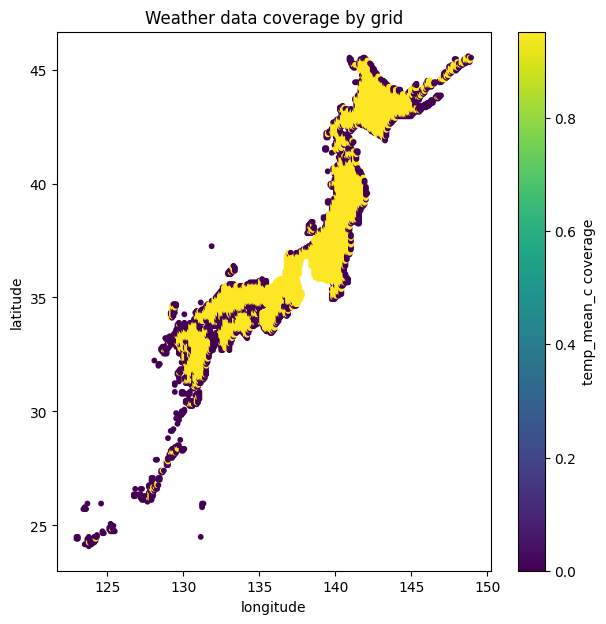

In [ ]:
import matplotlib.pyplot as plt

if {'centroid_lon', 'centroid_lat', 'temp_mean_c'}.issubset(grid_coverage.columns):
    plt.figure(figsize=(7, 7))
    plt.scatter(
        grid_coverage['centroid_lon'],
        grid_coverage['centroid_lat'],
        c=grid_coverage['temp_mean_c'],
        s=10
    )
    plt.colorbar(label='temp_mean_c coverage')
    plt.xlabel('longitude')
    plt.ylabel('latitude')
    plt.title('Weather data coverage by grid')
    plt.show()
else:
    print('可視化に必要な列がありません．')

## 12. 学習用に使う場合の注意

2026年6月以降など，気象データの取得期間外の週がパネルに含まれている場合，その週はNaNになりやすい．まずは欠損を除外したモデル用データを別名で保存しておくと安全である．ただし，欠損除外によって発生行が落ちすぎないかを確認してから使う．

In [ ]:
model_ready = panel_weather.dropna(subset=weather_cols).copy()
model_ready_path = f'{PROC_DIR}/hpai_weekly_grid_panel_with_weather_model_ready.parquet'
model_ready_sample_path = f'{PROC_DIR}/hpai_weekly_grid_panel_with_weather_model_ready_sample.csv'

model_ready.to_parquet(model_ready_path, index=False)
model_ready.head(10000).to_csv(model_ready_sample_path, index=False, encoding='utf-8-sig')

print('panel_weather:', panel_weather.shape)
print('model_ready:', model_ready.shape)
print('model_ready weeks:', model_ready['week_start'].min(), 'to', model_ready['week_start'].max())
print('Saved:', model_ready_path)
print('Saved sample:', model_ready_sample_path)

if event_col is not None:
    print('event rows original:', int((panel_weather[event_col] == 1).sum()))
    print('event rows model_ready:', int((model_ready[event_col] == 1).sum()))

panel_weather: (2176334, 34)
model_ready: (1641809, 34)
model_ready weeks: 2020-08-31 00:00:00 to 2026-05-18 00:00:00
Saved: /content/drive/MyDrive/avian_influenza_project/processed/hpai_weekly_grid_panel_with_weather_model_ready.parquet
Saved sample: /content/drive/MyDrive/avian_influenza_project/processed/hpai_weekly_grid_panel_with_weather_model_ready_sample.csv
event rows original: 208
event rows model_ready: 191


In [6]:
panel_weather = pd.read_parquet(f"{PROC_DIR}/hpai_weekly_grid_panel_with_weather.parquet")
panel_weather_model = pd.read_parquet(f"{PROC_DIR}/hpai_weekly_grid_panel_with_weather_model_ready.parquet")

weather_cols = ["temp_mean_c", "temp_min_c", "temp_max_c"]

print("全体:", panel_weather.shape)
print(panel_weather["week_start"].min(), panel_weather["week_start"].max())
print(panel_weather[weather_cols].isna().mean())

print("モデル用:", panel_weather_model.shape)
print(panel_weather_model["week_start"].min(), panel_weather_model["week_start"].max())
print(panel_weather_model[weather_cols].isna().mean())

event_all = panel_weather[panel_weather["outbreak_binary"] == 1]
event_model = panel_weather_model[panel_weather_model["outbreak_binary"] == 1]

print("全発生行:", len(event_all))
print("モデル用に残った発生行:", len(event_model))
print("発生行の残存率:", len(event_model) / len(event_all) if len(event_all) > 0 else None)

print("発生行の気象欠損率:")
print(event_all[weather_cols].isna().mean())

全体: (2176334, 34)
2020-08-31 00:00:00 2026-08-31 00:00:00
temp_mean_c    0.245608
temp_min_c     0.245608
temp_max_c     0.245608
dtype: float64
モデル用: (1641809, 34)
2020-08-31 00:00:00 2026-05-18 00:00:00
temp_mean_c    0.0
temp_min_c     0.0
temp_max_c     0.0
dtype: float64
全発生行: 208
モデル用に残った発生行: 191
発生行の残存率: 0.9182692307692307
発生行の気象欠損率:
temp_mean_c    0.081731
temp_min_c     0.081731
temp_max_c     0.081731
dtype: float64


In [7]:
weather_cols = ["temp_mean_c", "temp_min_c", "temp_max_c"]

panel_weather = pd.read_parquet(f"{PROC_DIR}/hpai_weekly_grid_panel_with_weather.parquet")
panel_weather["week_start"] = pd.to_datetime(panel_weather["week_start"])

event_missing_weather = panel_weather[
    (panel_weather["outbreak_binary"] == 1)
    & (panel_weather["temp_mean_c"].isna())
].copy()

print("気象欠損で落ちる発生行:", len(event_missing_weather))

cols = [
    "grid_id",
    "week_start",
    "outbreak_count",
    "centroid_lon",
    "centroid_lat",
    "temp_mean_c",
    "temp_min_c",
    "temp_max_c",
]

display(event_missing_weather[[c for c in cols if c in event_missing_weather.columns]])

# 欠損発生行の期間
print(event_missing_weather["week_start"].min(), event_missing_weather["week_start"].max())

# 欠損発生行のグリッド数
print("欠損発生グリッド数:", event_missing_weather["grid_id"].nunique())

気象欠損で落ちる発生行: 17


,grid_id,week_start,outbreak_count,temp_mean_c,temp_min_c,temp_max_c
31205,G000099,2022-12-12,1,NaN,NaN,NaN
136975,G000436,2022-01-10,1,NaN,NaN,NaN
165608,G000527,2023-02-27,1,NaN,NaN,NaN
330663,G001053,2021-01-25,1,NaN,NaN,NaN
330664,G001053,2021-02-01,1,NaN,NaN,NaN
330757,G001053,2022-11-14,1,NaN,NaN,NaN
1422756,G004531,2021-02-01,1,NaN,NaN,NaN
1422856,G004531,2023-01-02,1,NaN,NaN,NaN
1422962,G004531,2025-01-13,3,NaN,NaN,NaN
1422964,G004531,2025-01-27,4,NaN,NaN,NaN


2021-01-25 00:00:00 2026-02-16 00:00:00
欠損発生グリッド数: 7


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

weather_cols = ["temp_mean_c", "temp_min_c", "temp_max_c"]

panel_weather = pd.read_parquet(
    f"{PROC_DIR}/hpai_weekly_grid_panel_with_weather.parquet"
)
panel_weather["week_start"] = pd.to_datetime(panel_weather["week_start"])

panel_weather_model = pd.read_parquet(
    f"{PROC_DIR}/hpai_weekly_grid_panel_with_weather_model_ready.parquet"
)
panel_weather_model["week_start"] = pd.to_datetime(panel_weather_model["week_start"])

print("全体データ:", panel_weather.shape)
print("モデル用データ:", panel_weather_model.shape)

print("全体データ期間:", panel_weather["week_start"].min(), "～", panel_weather["week_start"].max())
print("モデル用期間:", panel_weather_model["week_start"].min(), "～", panel_weather_model["week_start"].max())

print("全体データの気象欠損率")
print(panel_weather[weather_cols].isna().mean())

print("モデル用データの気象欠損率")
print(panel_weather_model[weather_cols].isna().mean())

全体データ: (2176334, 34)
モデル用データ: (1641809, 34)
全体データ期間: 2020-08-31 00:00:00 ～ 2026-08-31 00:00:00
モデル用期間: 2020-08-31 00:00:00 ～ 2026-05-18 00:00:00
全体データの気象欠損率
temp_mean_c    0.245608
temp_min_c     0.245608
temp_max_c     0.245608
dtype: float64
モデル用データの気象欠損率
temp_mean_c    0.0
temp_min_c     0.0
temp_max_c     0.0
dtype: float64


In [9]:
event_all = panel_weather[panel_weather["outbreak_binary"] == 1].copy()
event_model = panel_weather_model[panel_weather_model["outbreak_binary"] == 1].copy()

print("全発生行:", len(event_all))
print("モデル用に残った発生行:", len(event_model))
print("気象欠損で落ちた発生行:", len(event_all) - len(event_model))

if len(event_all) > 0:
    print("発生行の残存率:", len(event_model) / len(event_all))

print("全発生グリッド数:", event_all["grid_id"].nunique())
print("モデル用に残った発生グリッド数:", event_model["grid_id"].nunique())

全発生行: 208
モデル用に残った発生行: 191
気象欠損で落ちた発生行: 17
発生行の残存率: 0.9182692307692307
全発生グリッド数: 123
モデル用に残った発生グリッド数: 116


In [10]:
event_missing_weather = panel_weather[
    (panel_weather["outbreak_binary"] == 1)
    & (panel_weather["temp_mean_c"].isna())
].copy()

print("気象欠損で落ちる発生行:", len(event_missing_weather))
print("欠損発生グリッド数:", event_missing_weather["grid_id"].nunique())

display(
    event_missing_weather[
        ["grid_id", "week_start", "outbreak_count"] + weather_cols
    ].sort_values(["grid_id", "week_start"])
)

気象欠損で落ちる発生行: 17
欠損発生グリッド数: 7


,grid_id,week_start,outbreak_count,temp_mean_c,temp_min_c,temp_max_c
31205,G000099,2022-12-12,1,NaN,NaN,NaN
136975,G000436,2022-01-10,1,NaN,NaN,NaN
165608,G000527,2023-02-27,1,NaN,NaN,NaN
330663,G001053,2021-01-25,1,NaN,NaN,NaN
330664,G001053,2021-02-01,1,NaN,NaN,NaN
330757,G001053,2022-11-14,1,NaN,NaN,NaN
1422756,G004531,2021-02-01,1,NaN,NaN,NaN
1422856,G004531,2023-01-02,1,NaN,NaN,NaN
1422962,G004531,2025-01-13,3,NaN,NaN,NaN
1422964,G004531,2025-01-27,4,NaN,NaN,NaN


In [11]:
print(panel_weather.columns.tolist())

['grid_id', 'week_start', 'year', 'week', 'year_week', 'month', 'outbreak_count', 'outbreak_binary', 'num_birds_sum', 'weekofyear', 'sin_week', 'cos_week', 'season', 'lag_outbreak_1w', 'lag_outbreak_2w', 'lag_outbreak_4w', 'lag_outbreak_8w', 'rolling_outbreak_4w', 'rolling_outbreak_8w', 'rolling_outbreak_12w', 'y_lead_1w', 'y_lead_2w', 'y_lead_4w', 'neighbor_outbreak_count', 'neighbor_outbreak_binary', 'neighbor_outbreak_count_past_1w', 'neighbor_outbreak_count_past_2w', 'neighbor_outbreak_count_past_4w', 'neighbor_outbreak_count_past_8w', 'grid_lat', 'grid_lon', 'temp_mean_c', 'temp_min_c', 'temp_max_c']


In [12]:
# 緯度経度列を準備する

lon_candidates = ["centroid_lon", "grid_lon", "lon", "longitude"]
lat_candidates = ["centroid_lat", "grid_lat", "lat", "latitude"]

lon_col = next((c for c in lon_candidates if c in panel_weather.columns), None)
lat_col = next((c for c in lat_candidates if c in panel_weather.columns), None)

if lon_col is not None and lat_col is not None:
    print("panel_weather内の緯度経度列を使用:", lon_col, lat_col)

    event_missing_weather_geo = event_missing_weather.copy()
    event_missing_weather_geo["lon_for_plot"] = event_missing_weather_geo[lon_col]
    event_missing_weather_geo["lat_for_plot"] = event_missing_weather_geo[lat_col]

else:
    print("panel_weather内に緯度経度列がないため，grid_pointsから結合します．")
    print("grid_points columns:", grid_points.columns.tolist())

    lon_col_gp = next((c for c in lon_candidates if c in grid_points.columns), None)
    lat_col_gp = next((c for c in lat_candidates if c in grid_points.columns), None)

    if lon_col_gp is None or lat_col_gp is None:
        raise ValueError("grid_pointsにも緯度経度列が見つかりません．列名を確認してください．")

    event_missing_weather_geo = event_missing_weather.merge(
        grid_points[["grid_id", lon_col_gp, lat_col_gp]].drop_duplicates("grid_id"),
        on="grid_id",
        how="left"
    )

    event_missing_weather_geo["lon_for_plot"] = event_missing_weather_geo[lon_col_gp]
    event_missing_weather_geo["lat_for_plot"] = event_missing_weather_geo[lat_col_gp]

display(
    event_missing_weather_geo[
        ["grid_id", "week_start", "outbreak_count", "lon_for_plot", "lat_for_plot"]
    ].sort_values(["grid_id", "week_start"])
)

panel_weather内の緯度経度列を使用: grid_lon grid_lat


,grid_id,week_start,outbreak_count,lon_for_plot,lat_for_plot
31205,G000099,2022-12-12,1,127.918256,26.442316
136975,G000436,2022-01-10,1,130.164044,32.157233
165608,G000527,2023-02-27,1,130.343707,33.590648
330663,G001053,2021-01-25,1,131.511517,32.081150
330664,G001053,2021-02-01,1,131.511517,32.081150
330757,G001053,2022-11-14,1,131.511517,32.081150
1422756,G004531,2021-02-01,1,140.674333,35.733168
1422856,G004531,2023-01-02,1,140.674333,35.733168
1422962,G004531,2025-01-13,3,140.674333,35.733168
1422964,G004531,2025-01-27,4,140.674333,35.733168


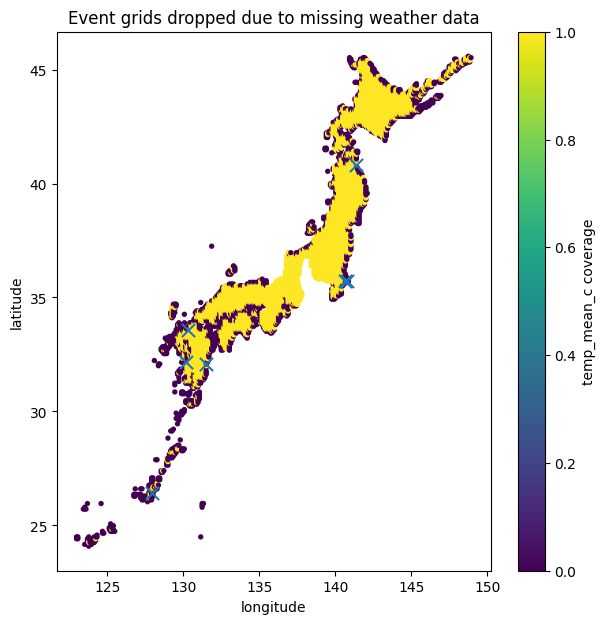

,grid_id,temp_mean_c,temp_min_c,temp_max_c,lon_for_plot,lat_for_plot
99,G000099,0.0,0.0,0.0,127.918256,26.442316
436,G000436,0.0,0.0,0.0,130.164044,32.157233
527,G000527,0.0,0.0,0.0,130.343707,33.590648
1053,G001053,0.0,0.0,0.0,131.511517,32.081150
4531,G004531,0.0,0.0,0.0,140.674333,35.733168
4626,G004626,0.0,0.0,0.0,140.764165,35.733168
5198,G005198,0.0,0.0,0.0,141.392985,40.807352


In [13]:
# 全グリッドの気象カバレッジを作る

grid_coverage = (
    panel_weather
    .groupby("grid_id")[weather_cols]
    .apply(lambda x: x.notna().mean())
    .reset_index()
)

# 緯度経度を付ける
if lon_col is not None and lat_col is not None:
    grid_geo = (
        panel_weather[["grid_id", lon_col, lat_col]]
        .drop_duplicates("grid_id")
        .rename(columns={lon_col: "lon_for_plot", lat_col: "lat_for_plot"})
    )
else:
    grid_geo = (
        grid_points[["grid_id", lon_col_gp, lat_col_gp]]
        .drop_duplicates("grid_id")
        .rename(columns={lon_col_gp: "lon_for_plot", lat_col_gp: "lat_for_plot"})
    )

grid_coverage_map = grid_coverage.merge(
    grid_geo,
    on="grid_id",
    how="left"
)

missing_event_grids = event_missing_weather["grid_id"].unique()

missing_points = grid_coverage_map[
    grid_coverage_map["grid_id"].isin(missing_event_grids)
].copy()

plt.figure(figsize=(7, 7))

plt.scatter(
    grid_coverage_map["lon_for_plot"],
    grid_coverage_map["lat_for_plot"],
    c=grid_coverage_map["temp_mean_c"],
    s=8
)

plt.scatter(
    missing_points["lon_for_plot"],
    missing_points["lat_for_plot"],
    s=90,
    marker="x"
)

plt.colorbar(label="temp_mean_c coverage")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Event grids dropped due to missing weather data")
plt.show()

display(missing_points.sort_values("grid_id"))

In [14]:
df_model = panel_weather_model.copy()

print("学習用データ:", df_model.shape)
print("期間:", df_model["week_start"].min(), "～", df_model["week_start"].max())
print("グリッド数:", df_model["grid_id"].nunique())
print("発生行数:", (df_model["outbreak_binary"] == 1).sum())
print("発生率:", df_model["outbreak_binary"].mean())

print("気象欠損率")
print(df_model[weather_cols].isna().mean())

# 念のため保存
df_model.to_parquet(
    f"{PROC_DIR}/hpai_weekly_grid_panel_for_model.parquet",
    index=False
)

df_model.to_csv(
    f"{PROC_DIR}/hpai_weekly_grid_panel_for_model.csv",
    index=False,
    encoding="utf-8-sig"
)

print("保存完了:")
print(f"{PROC_DIR}/hpai_weekly_grid_panel_for_model.parquet")
print(f"{PROC_DIR}/hpai_weekly_grid_panel_for_model.csv")

学習用データ: (1641809, 34)
期間: 2020-08-31 00:00:00 ～ 2026-05-18 00:00:00
グリッド数: 5491
発生行数: 191
発生率: 0.00011633509135350093
気象欠損率
temp_mean_c    0.0
temp_min_c     0.0
temp_max_c     0.0
dtype: float64
保存完了:
/content/drive/MyDrive/avian_influenza_project/processed/hpai_weekly_grid_panel_for_model.parquet
/content/drive/MyDrive/avian_influenza_project/processed/hpai_weekly_grid_panel_for_model.csv


## 13. 判定の目安

以下を満たしていれば，気象結合はおおむね成功している．

- `missing files = 0`
- `bad files = 0`
- `duplicates grid_id × week_start = 0`
- `bad weekly temp order rows = 0`
- 発生行の気象欠損率が低い
- 欠損がある場合，それが主に取得期間外の未来週，またはERA5-Land対象外の地点に限定されている

現在のREQUESTSでは気温3変数のみである．鳥インフルエンザ予測モデルを強化する場合は，降水量，積雪，湿度，風速，水田・水域・畜産密度などを次に追加するとよい．